In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import time
import warnings
warnings.filterwarnings('ignore')

#Evaluation our model

from sklearn.metrics import mean_squared_error,mean_absolute_error
from statsmodels.tools.eval_measures import rmse


In [2]:
df = pd.read_csv("forecast train.csv")

df['date'] = pd.to_datetime(df['date'])
import datetime
def create_date_features(df):
    df['month'] = df.date.dt.month
    df['day'] = df.date.dt.day
    df['year'] = df.date.dt.year
    return df


# Time series forecasting with ARIMA 

In [3]:
!pip install pmdarima

In [4]:
from pmdarima import auto_arima



In [5]:

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    print('Best model for store '+str(i))
    store_i_model = auto_arima(store_i,m=12,seasonal=True,trace=True)
    print('  ' ,store_i_model.summary())   
    print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
    print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')


Best model for store 1
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=3.50 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=509.051, Time=0.18 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=512.111, Time=0.23 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=512.275, Time=0.16 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=510.737, Time=0.14 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=510.853, Time=0.13 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.29 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=510.569, Time=0.10 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=510.533, Time=0.19 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=512.514, Time=0.18 sec
 ARIMA(0,1,0)(0,1,0)[12] intercept   : AIC=510.926, Time=0.04 sec

Best model:  ARIMA(0,1,0)(0,1,0)[12]          
Total fit time: 6.667 seconds
                                        SARIMAX Results                                      
Dep. Variable:                              

 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=1.51 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=514.977, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=518.399, Time=0.20 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=518.493, Time=0.20 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=516.724, Time=0.12 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=516.826, Time=0.17 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.71 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=516.679, Time=0.11 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=516.648, Time=0.10 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=518.629, Time=0.15 sec
 ARIMA(0,1,0)(0,1,0)[12] intercept   : AIC=516.853, Time=0.02 sec

Best model:  ARIMA(0,1,0)(0,1,0)[12]          
Total fit time: 3.365 seconds
                                        SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   60
Model:             

 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=1.29 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=482.062, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=485.101, Time=0.16 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=485.133, Time=0.14 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=484.049, Time=0.09 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=484.053, Time=0.15 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.40 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=483.119, Time=0.08 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=483.142, Time=0.09 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=485.119, Time=0.11 sec
 ARIMA(0,1,0)(0,1,0)[12] intercept   : AIC=483.917, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,1,0)[12]          
Total fit time: 2.628 seconds
                                        SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   60
Model:             

 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=1.35 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=531.800, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=532.331, Time=0.22 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=533.006, Time=0.23 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=531.354, Time=0.16 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=531.088, Time=0.58 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=0.99 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=0.13 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=529.441, Time=0.28 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=531.423, Time=0.61 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.56 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=530.316, Time=0.50 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=531.026, Time=0.44 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=529.209, Time=0.29 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=532.215, Time=0.13 sec
 ARIMA(0,1,1)(2,1,1)[12]  

In [6]:
for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    store_i_model = auto_arima(store_i,m=12,seasonal=True)           #,trace=True)
    print('Best model for store '+str(i)+':',store_i_model)


Best model for store 1:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 2:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 3:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 4:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 5:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 6:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 7:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 8:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 9:  ARIMA(0,1,0)(0,1,0)[12]          
Best model for store 10:  ARIMA(0,1,1)(2,1,0)[12]          


In [24]:



from statsmodels.tsa.statespace.sarimax import SARIMAX

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    start_i = len(store_i_train)
    end_i = len(store_i_train) + len(store_i_test) - 1

    
    store_i_model = auto_arima(store_i,m=12,seasonal=True)
    orders=[(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,1)]
    seasonal_order=[(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(2,1,0,12)]
    
    store_i_model = SARIMAX(store_i_train,order=orders[i-1],seasonal_order=seasonal_order[i-1],enforce_invertibility=False)
    store_i_result = store_i_model.fit()
    store_i_prediction = store_i_result.predict(start_i,end_i).rename('SARIMA model predictions')
    print('rmse of store'+str(i)+':',rmse(store_i_test,store_i_prediction))

rmse of store1: 84.00605349899561
rmse of store2: 99.89134081126008
rmse of store3: 79.34385672449186
rmse of store4: 77.54930681293042
rmse of store5: 61.16243642312346
rmse of store6: 52.507506234600314
rmse of store7: 52.03590672667766
rmse of store8: 100.49471951371982
rmse of store9: 63.818170080352594
rmse of store10: 40.117617326087625


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store1


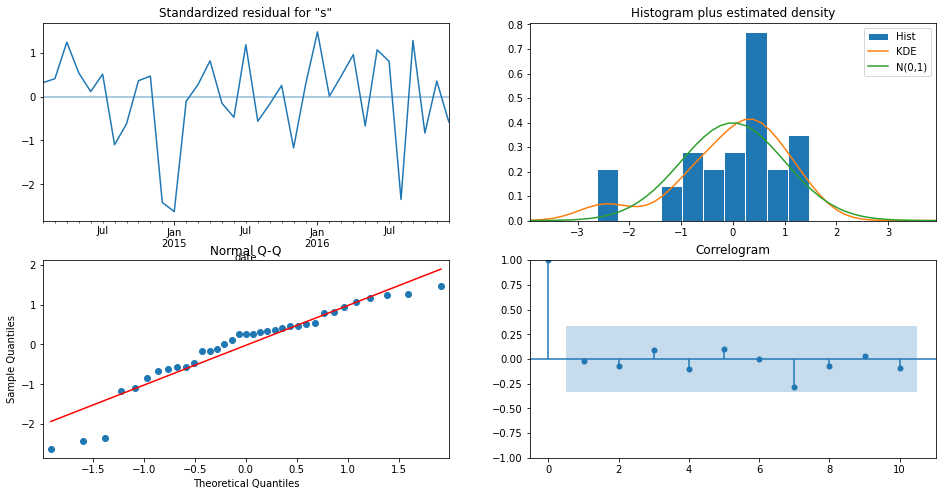

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store2


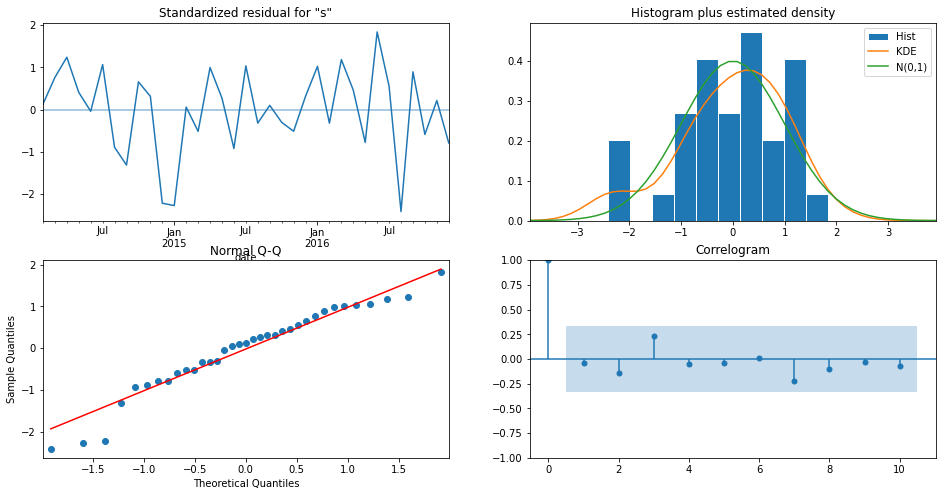

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store3


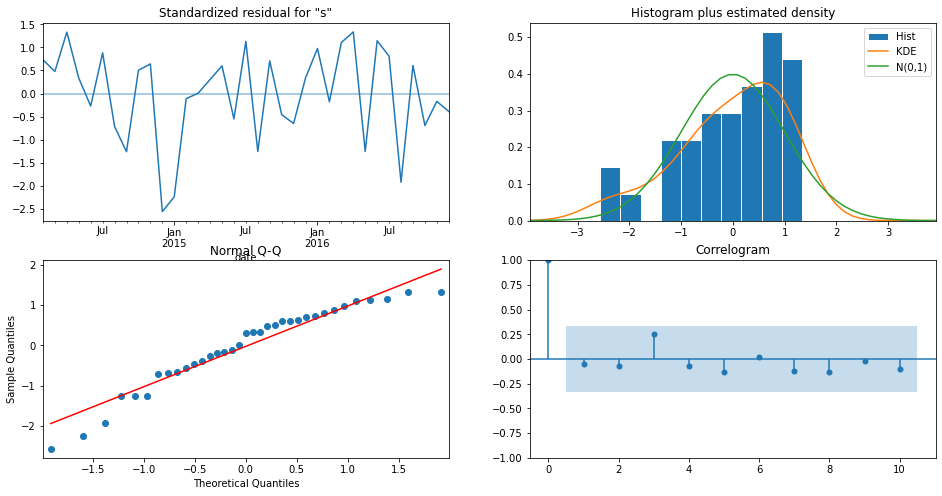

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store4


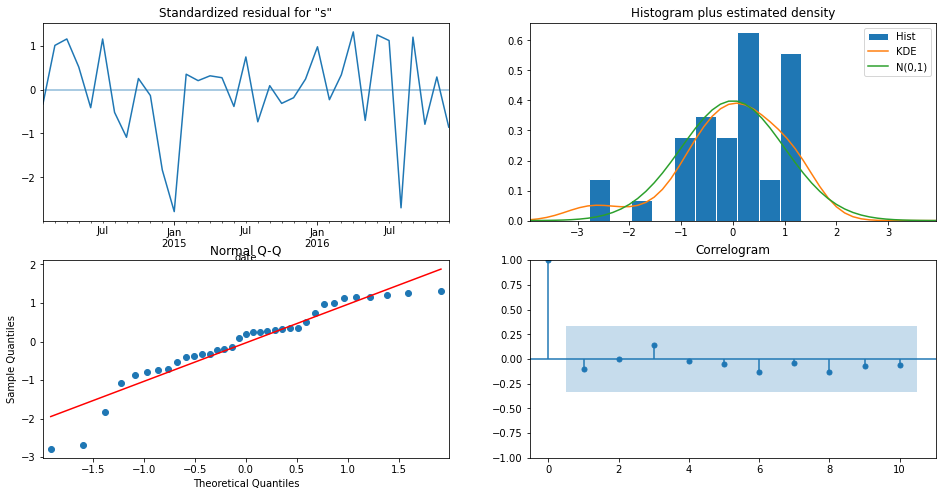

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store5


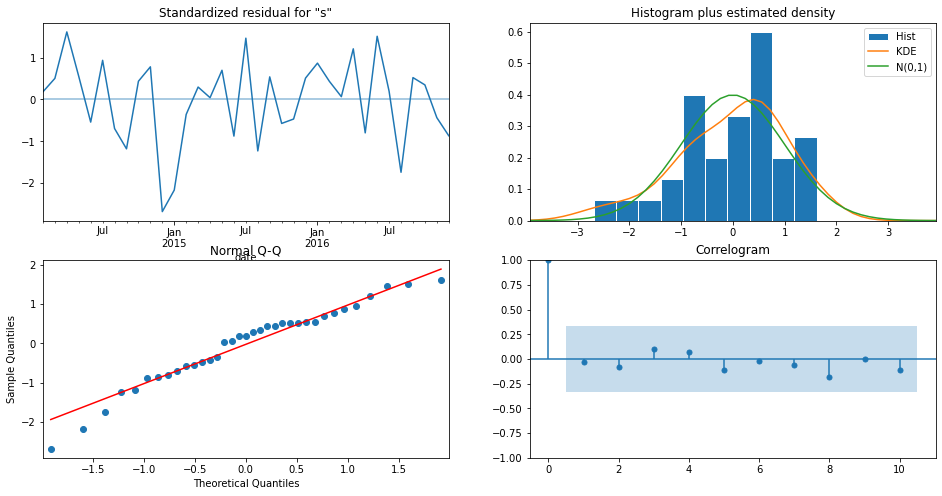

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store6


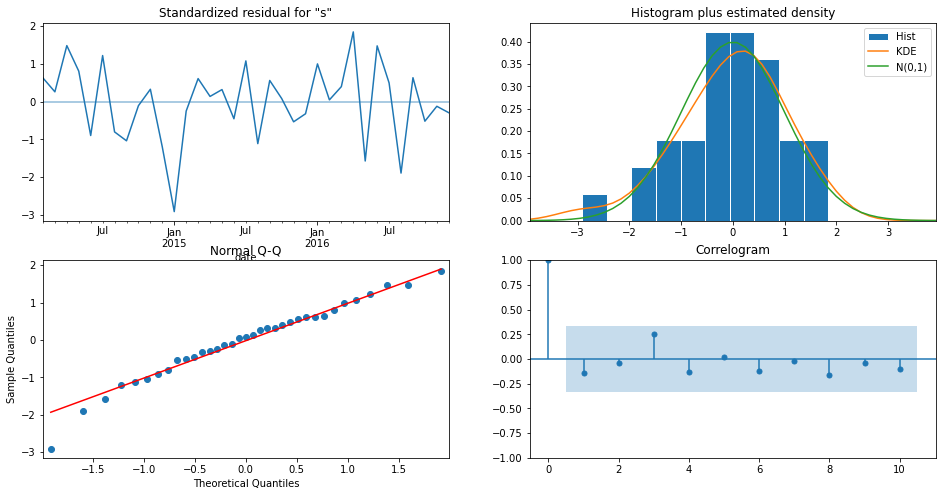

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store7


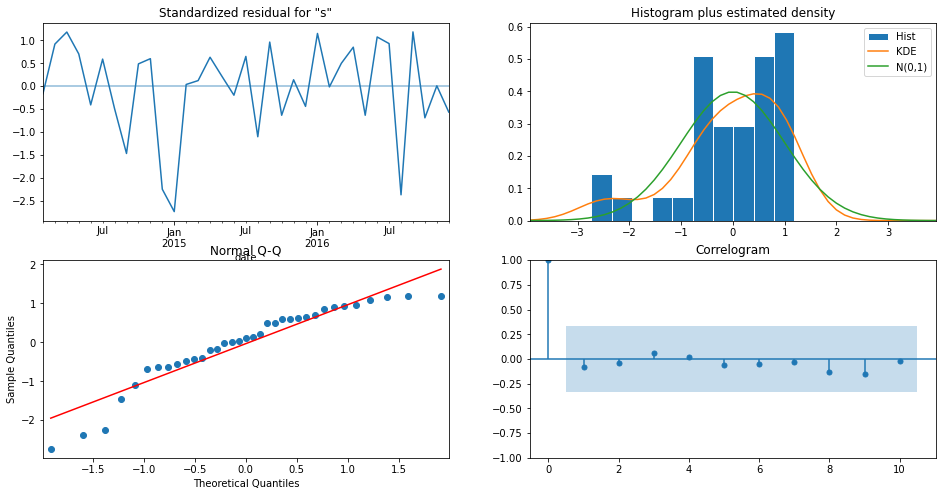

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store8


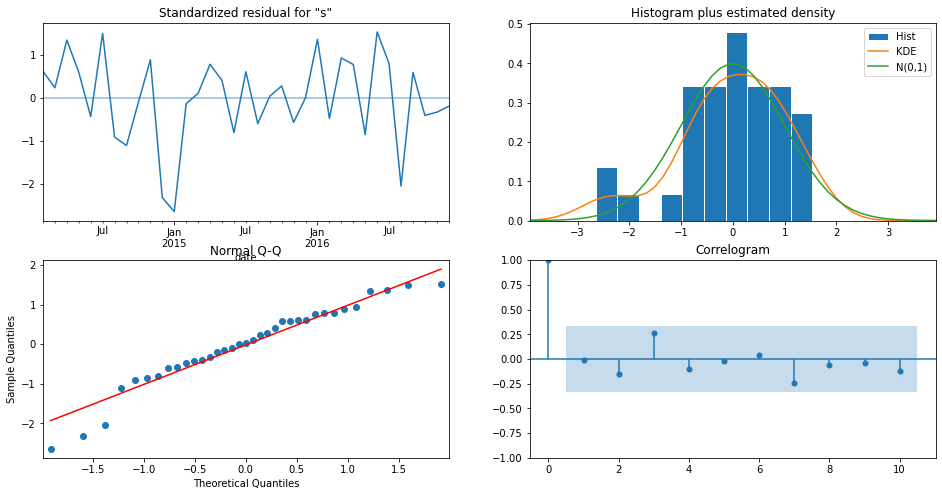

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store9


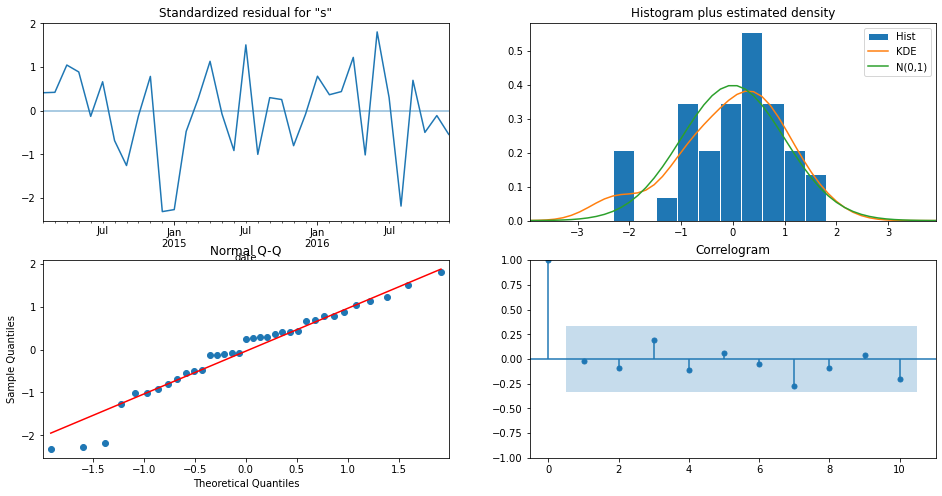

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
store10


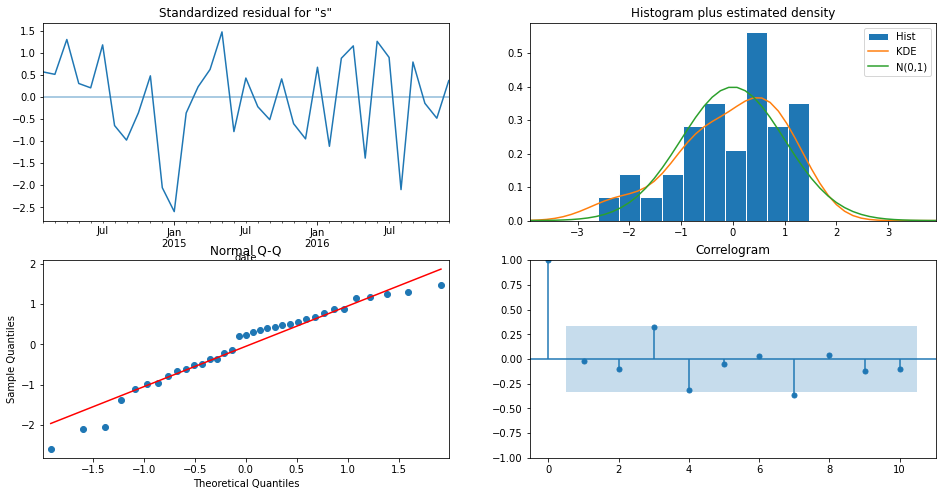

In [35]:



from statsmodels.tsa.statespace.sarimax import SARIMAX

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    start_i = len(store_i_train)
    end_i = len(store_i_train) + len(store_i_test) - 1

    
    store_i_model = auto_arima(store_i,m=12,seasonal=True)
    orders=[(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,1)]
    seasonal_order=[(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(2,1,0,12)]
    
    store_i_model = SARIMAX(store_i_train,order=orders[i-1],seasonal_order=seasonal_order[i-1],enforce_invertibility=False)
    store_i_result = store_i_model.fit()
    print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
    print('store'+str(i))
    store_i_result.plot_diagnostics(figsize=(16,8))
    plt.show()

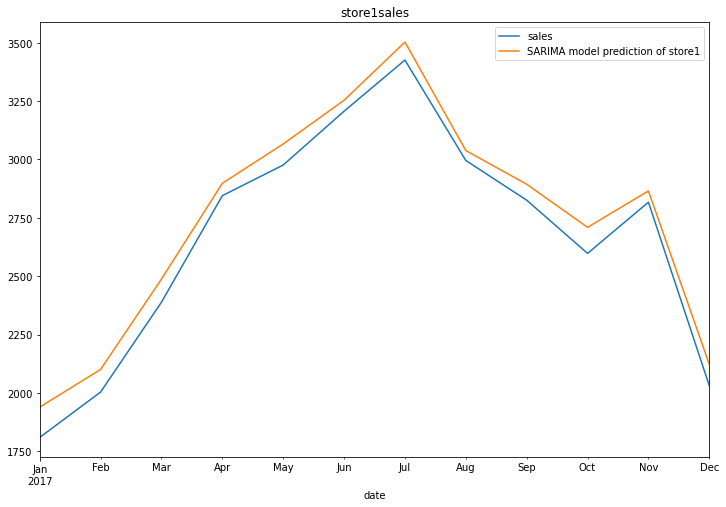

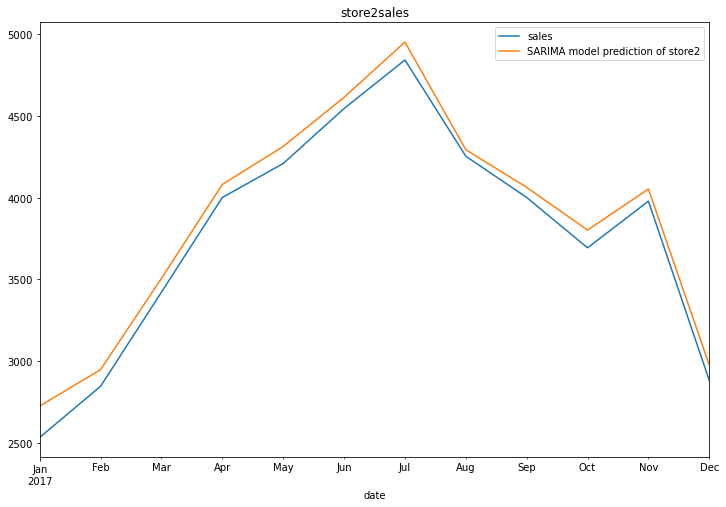

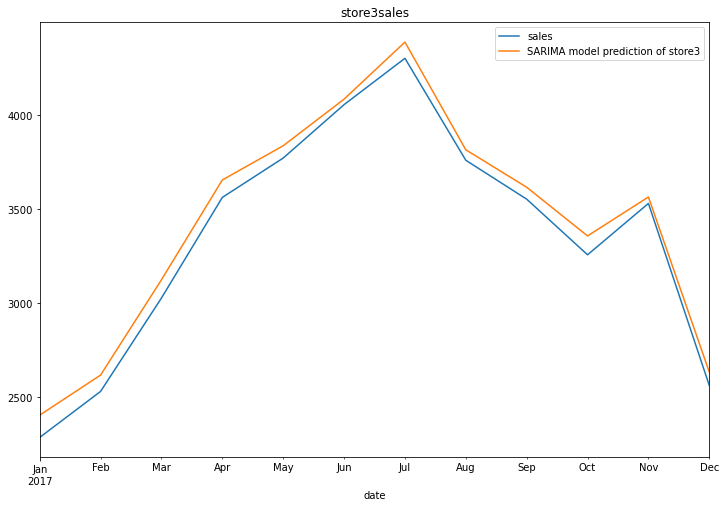

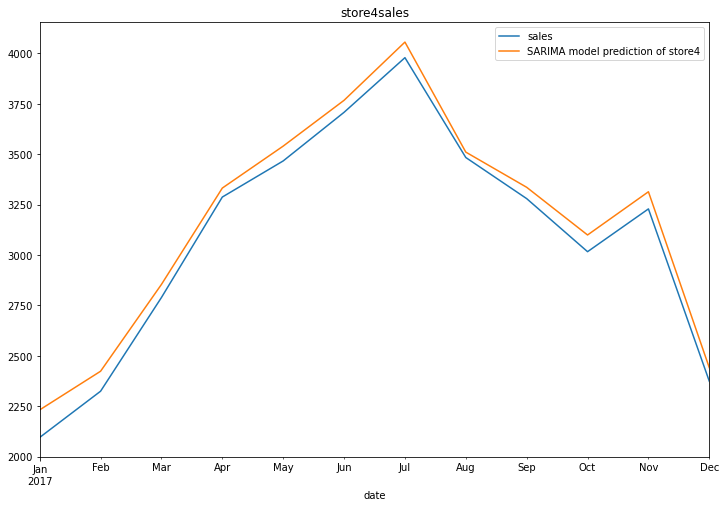

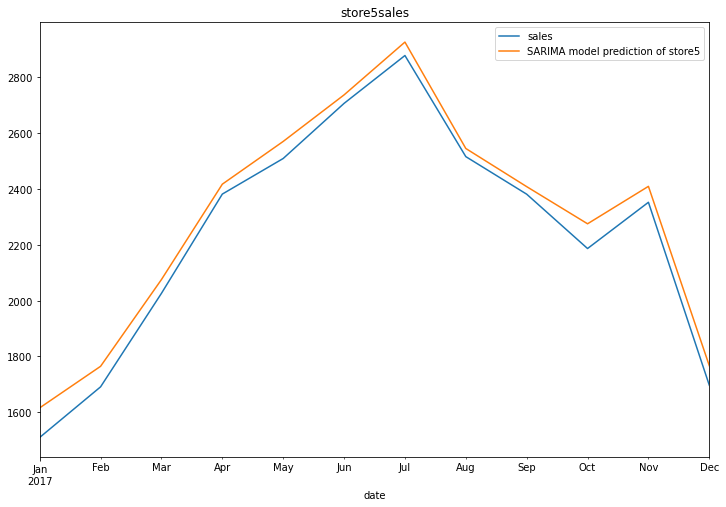

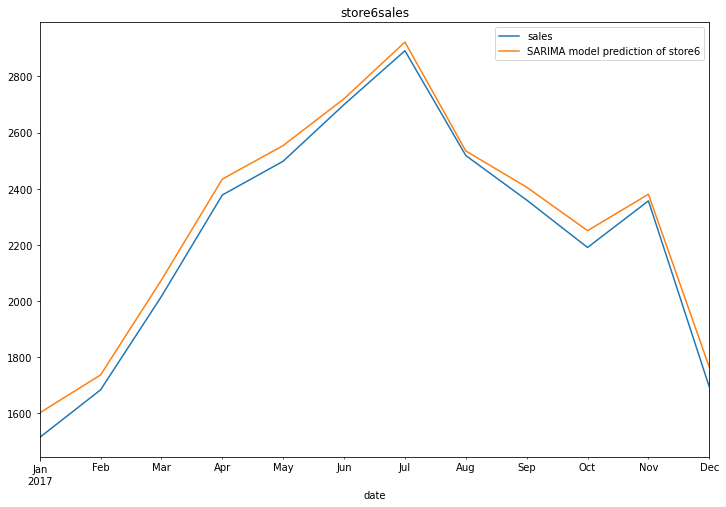

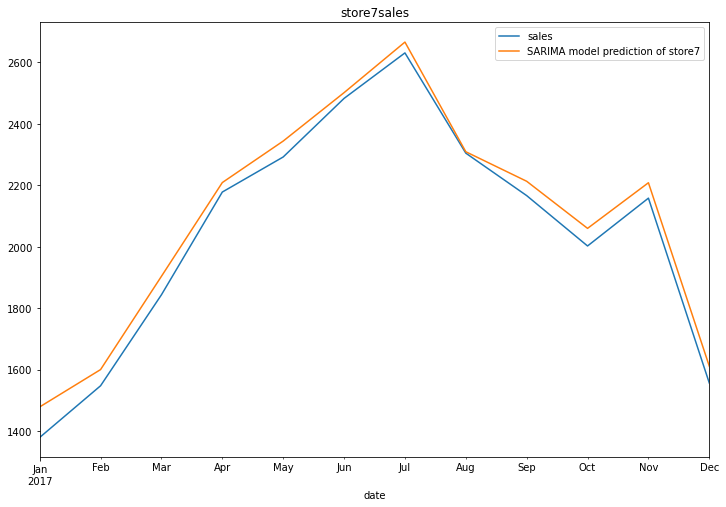

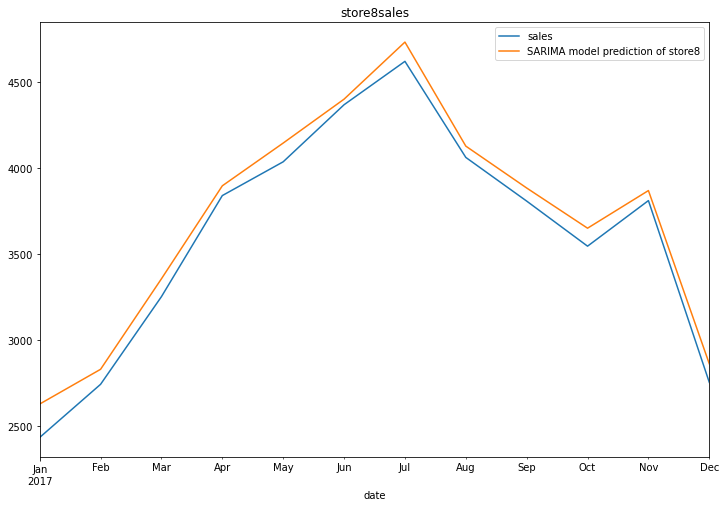

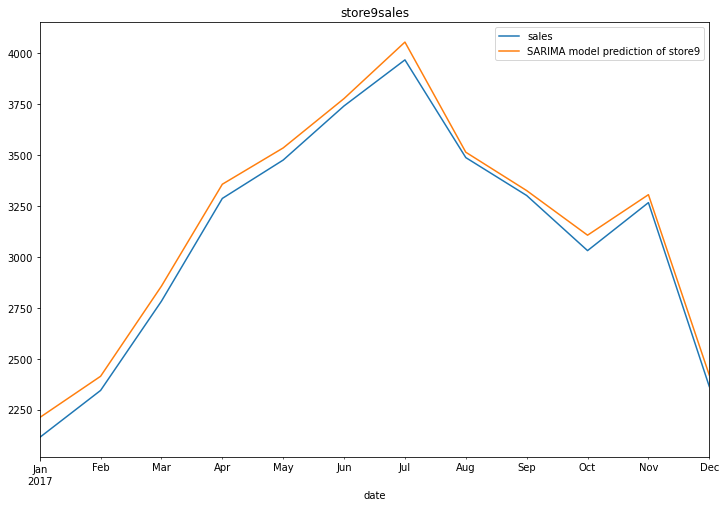

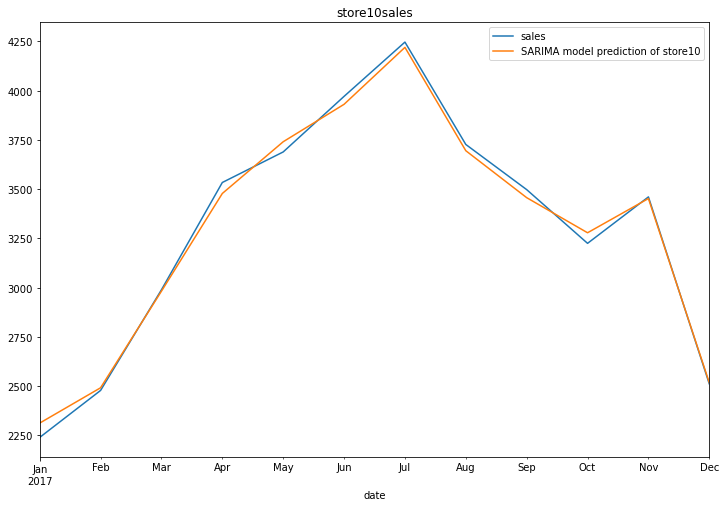

In [42]:



from statsmodels.tsa.statespace.sarimax import SARIMAX

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    start_i = len(store_i_train)
    end_i = len(store_i_train) + len(store_i_test) - 1

    
    store_i_model = auto_arima(store_i,m=12,seasonal=True)
    orders=[(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,1)]
    seasonal_order=[(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(2,1,0,12)]
    
    store_i_model = SARIMAX(store_i_train,order=orders[i-1],seasonal_order=seasonal_order[i-1],enforce_invertibility=False)
    store_i_result = store_i_model.fit()
    store_i_prediction = store_i_result.predict(start_i,end_i).rename('SARIMA model prediction of store'+str(i))
    
    store_i_test.plot(figsize=(12,8),legend=True)
    store_i_prediction.plot(legend=True)
    plt.title("store" +str(i)+ "sales")
    plt.show()

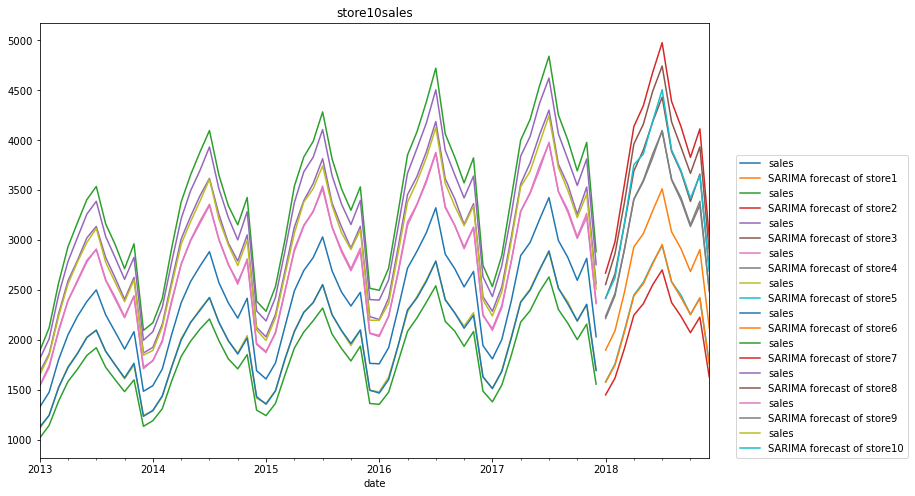

In [41]:




from statsmodels.tsa.statespace.sarimax import SARIMAX

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    start_i = len(store_i_train)
    end_i = len(store_i_train) + len(store_i_test) - 1

    
    store_i_model = auto_arima(store_i,m=12,seasonal=True)
    orders=[(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,1)]
    seasonal_order=[(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(2,1,0,12)]
    
    
    store_i_model_final = SARIMAX(store_i,order=orders[i-1],seasonal_order=seasonal_order[i-1],enforce_invertibility=False)
    store_i_result_final = store_i_model_final.fit()
    store_i_forecast = store_i_result_final.predict(len(store_i),len(store_i)+11,typ='levels').rename('SARIMA forecast of store'+str(i))
    store_i.plot(legend=True,figsize=(12,8))
    store_i_forecast.plot(legend=True)
    plt.title("store sales")
    plt.legend(loc=(1.04, 0))
    


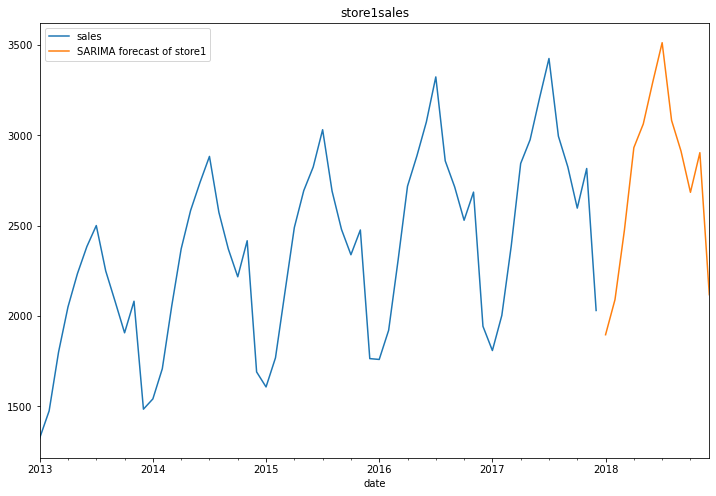

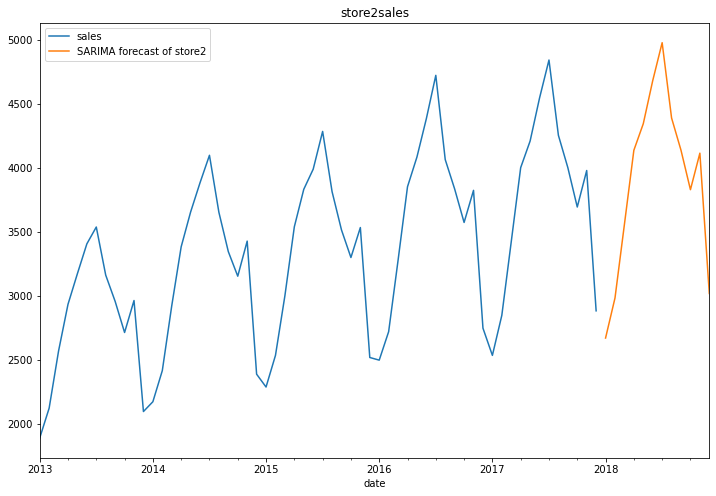

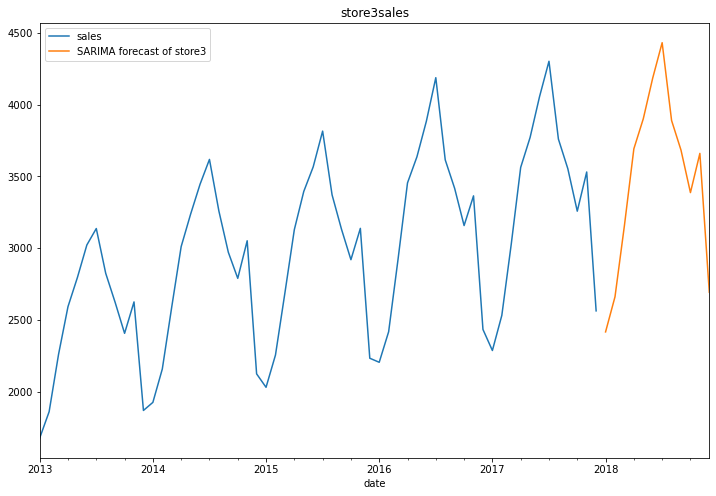

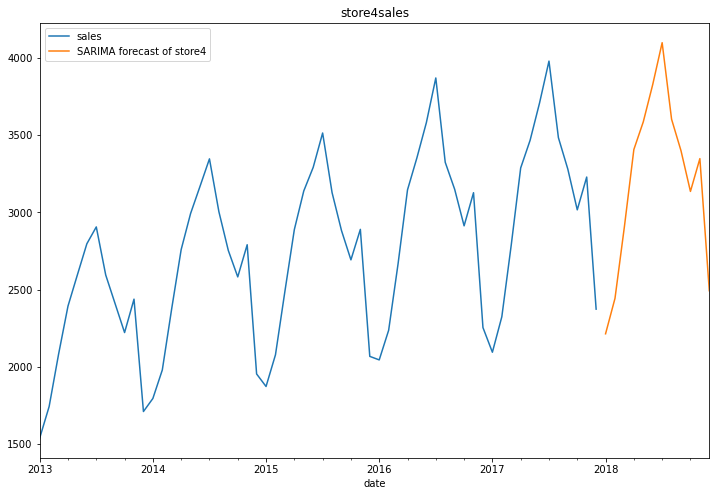

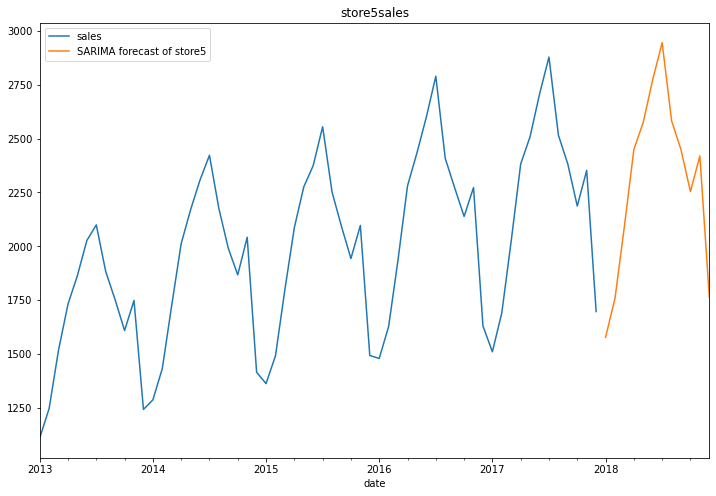

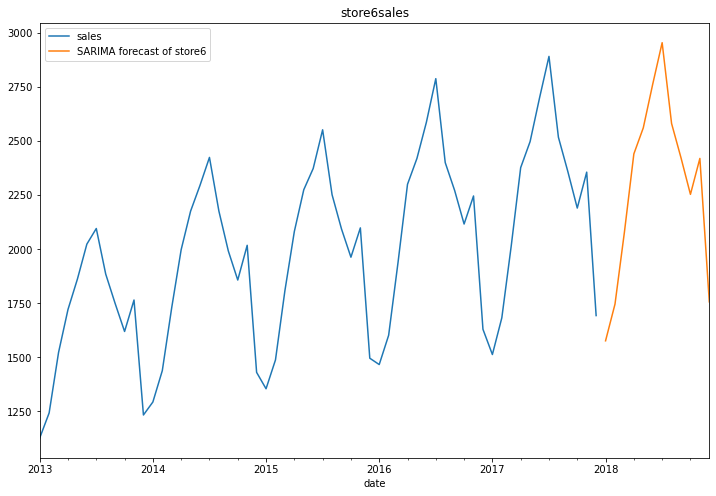

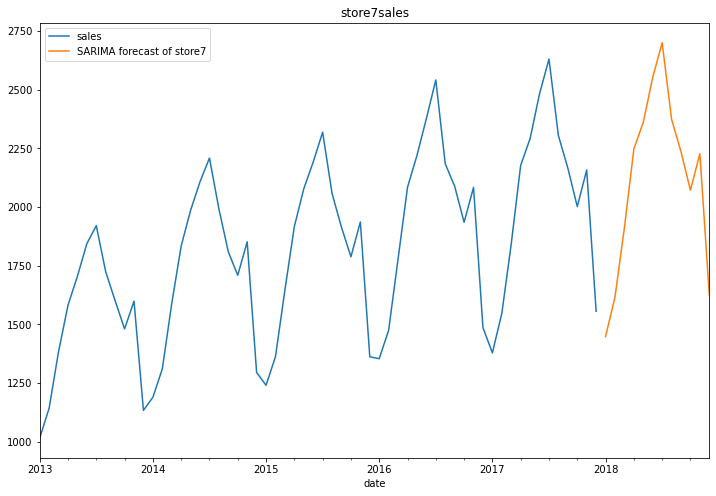

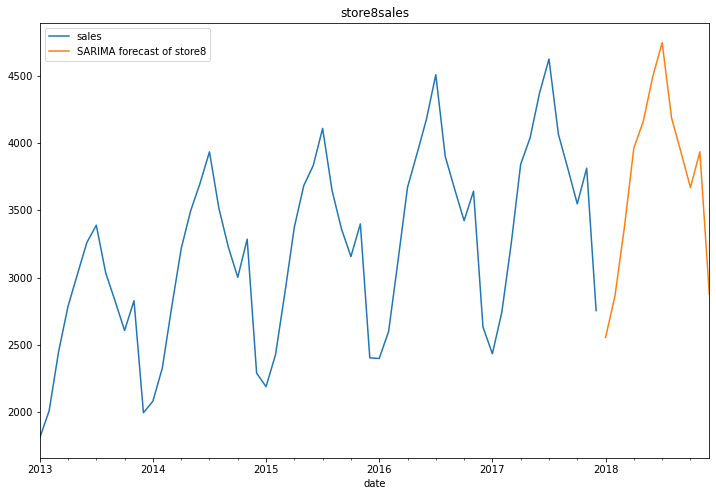

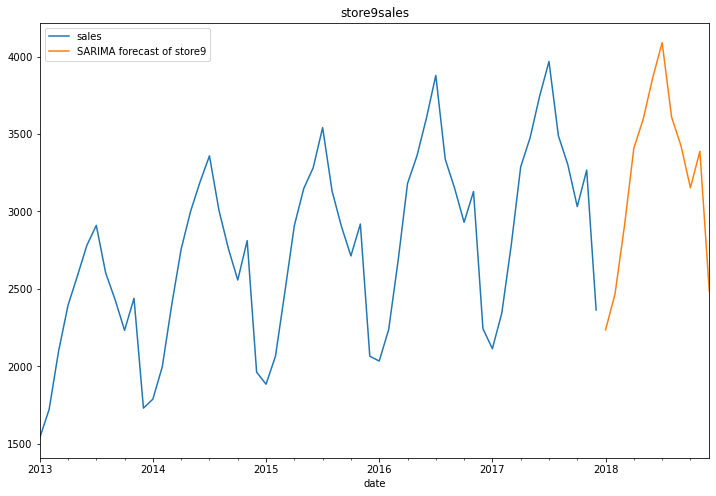

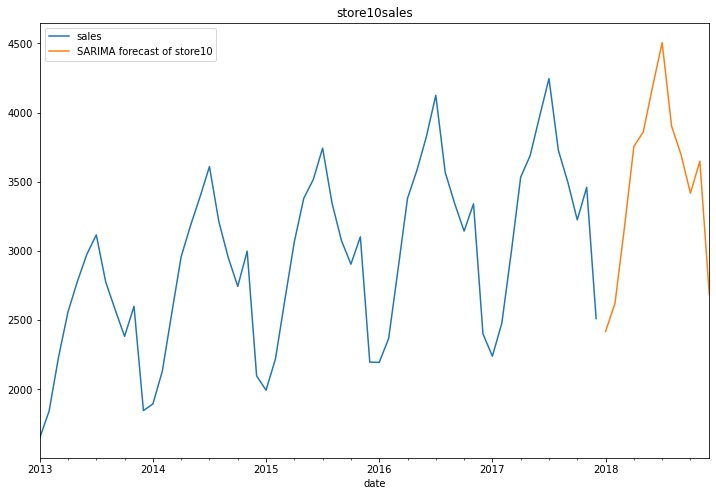

In [44]:
#Now let us forecast into the unknown future



from statsmodels.tsa.statespace.sarimax import SARIMAX

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    start_i = len(store_i_train)
    end_i = len(store_i_train) + len(store_i_test) - 1

    
    store_i_model = auto_arima(store_i,m=12,seasonal=True)
    orders=[(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,1)]
    seasonal_order=[(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(2,1,0,12)]
    
    
    store_i_model_final = SARIMAX(store_i,order=orders[i-1],seasonal_order=seasonal_order[i-1],enforce_invertibility=False)
    store_i_result_final = store_i_model_final.fit()
    store_i_forecast = store_i_result_final.predict(len(store_i),len(store_i)+11,typ='levels').rename('SARIMA forecast of store'+str(i))
    store_i.plot(legend=True,figsize=(12,8))
    store_i_forecast.plot(legend=True)
    plt.title("store" +str(i)+ "sales")
    #plt.legend(loc=(1.04, 0))
    plt.show()


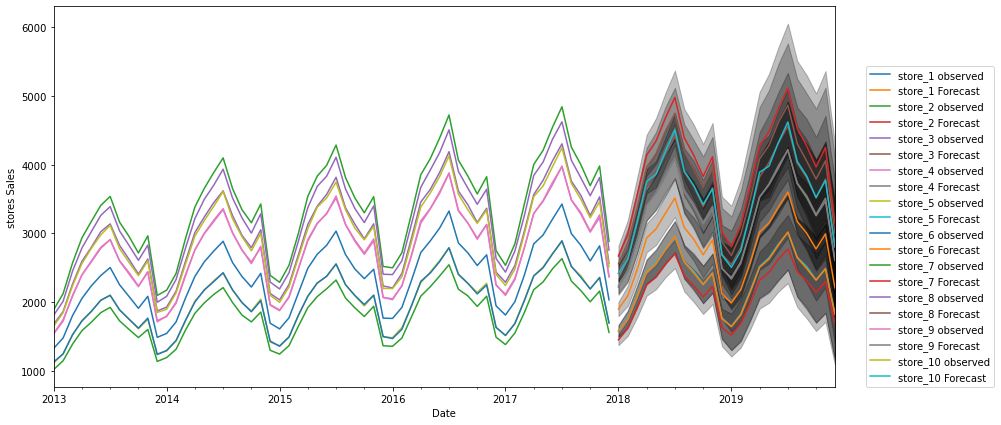

In [52]:
#Now let us forecast into the unknown future



from statsmodels.tsa.statespace.sarimax import SARIMAX

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    start_i = len(store_i_train)
    end_i = len(store_i_train) + len(store_i_test) - 1

    
    store_i_model = auto_arima(store_i,m=12,seasonal=True)
    orders=[(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,1)]
    seasonal_order=[(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(2,1,0,12)]
    
    store_i_model_final = SARIMAX(store_i,order=orders[i-1],seasonal_order=seasonal_order[i-1],enforce_invertibility=False)
    store_i_result_final = store_i_model_final.fit()
    store_i_pred = store_i_result_final.get_forecast(steps=24)
    store_i_pred_ci = store_i_pred.conf_int()
    ax = store_i.plot(label='store_'+str(i)+ ' observed',figsize=(14,7))
    store_i_pred.predicted_mean.plot(ax=ax,label='store_'+str(i)+ ' Forecast')
    ax.fill_between(store_i_pred_ci.index,
               store_i_pred_ci.iloc[:,0],
               store_i_pred_ci.iloc[:,1],color='k',alpha=.25)
    ax.set_xlabel('Date')
    ax.set_ylabel('stores Sales')
    plt.legend(loc=(1.04, 0))
    #plt.show()
    
    
    
    
    
    


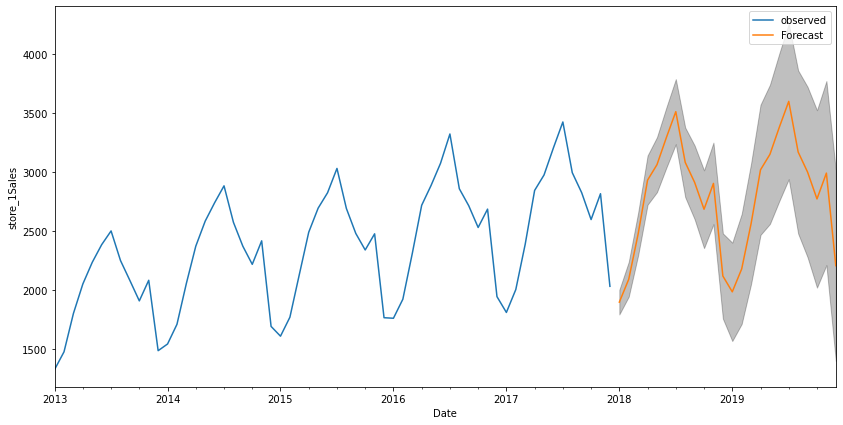

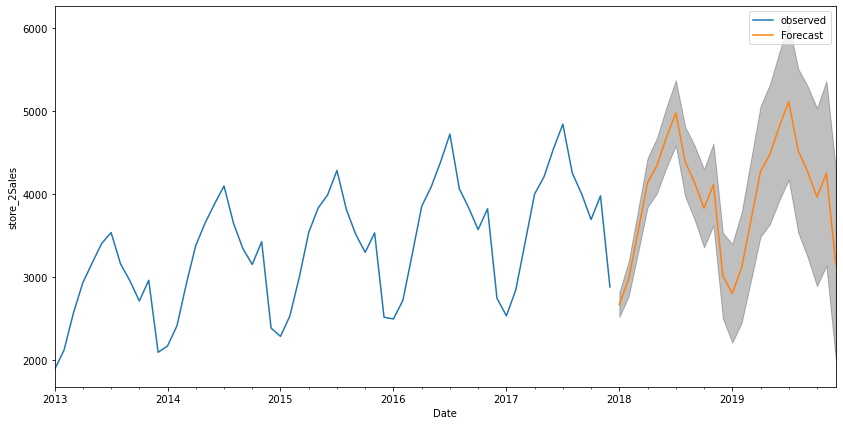

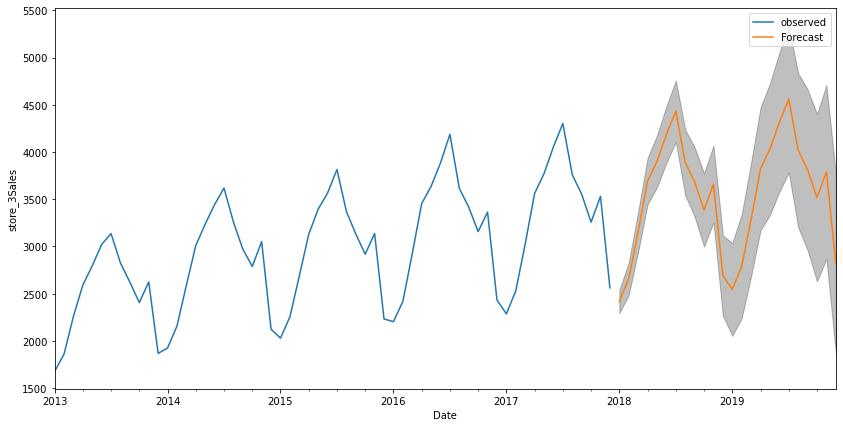

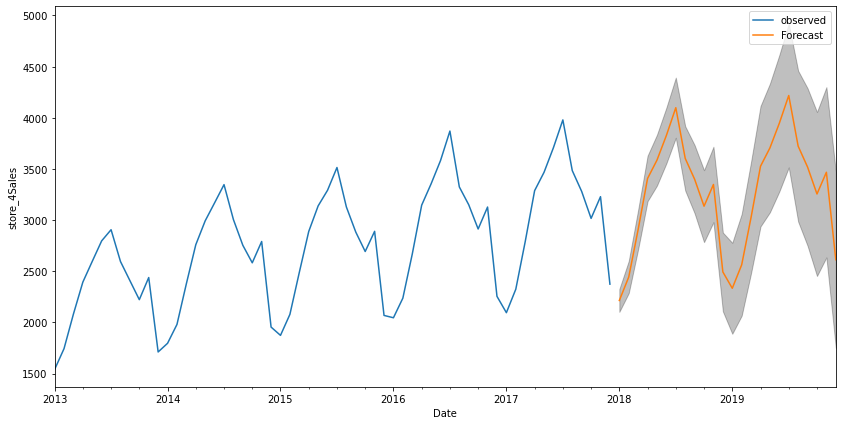

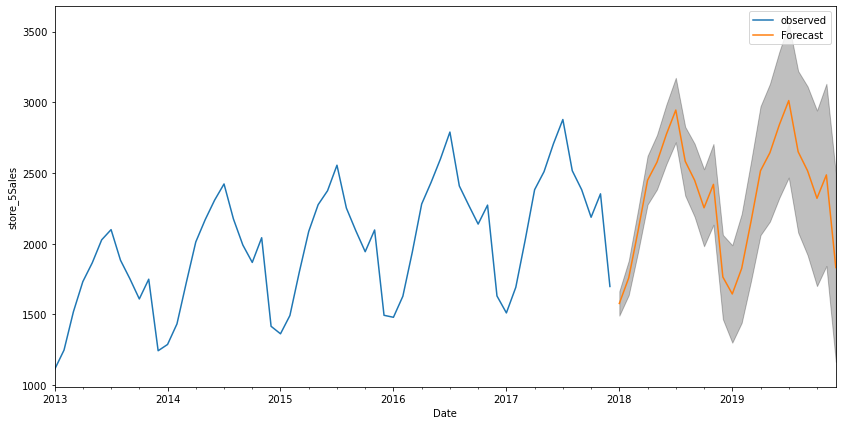

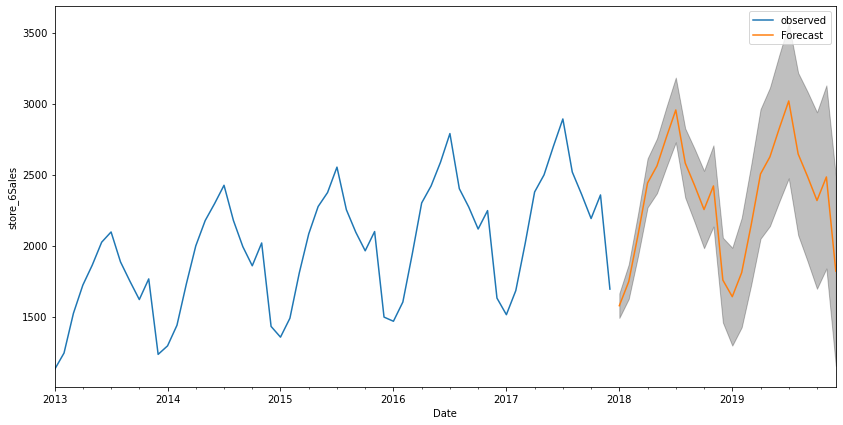

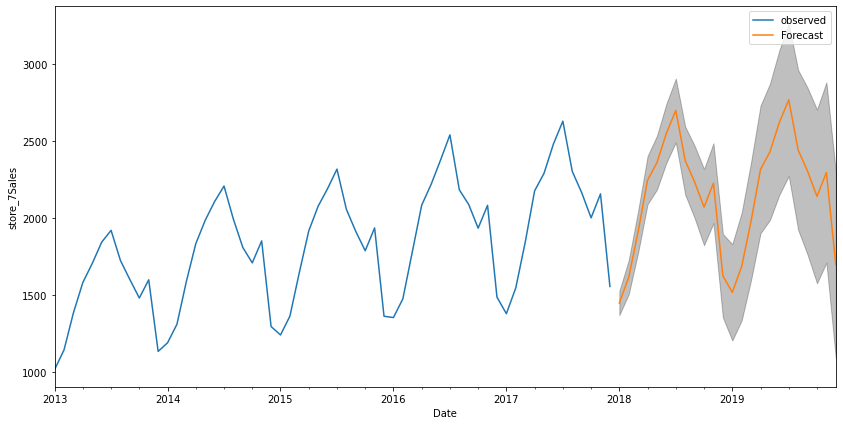

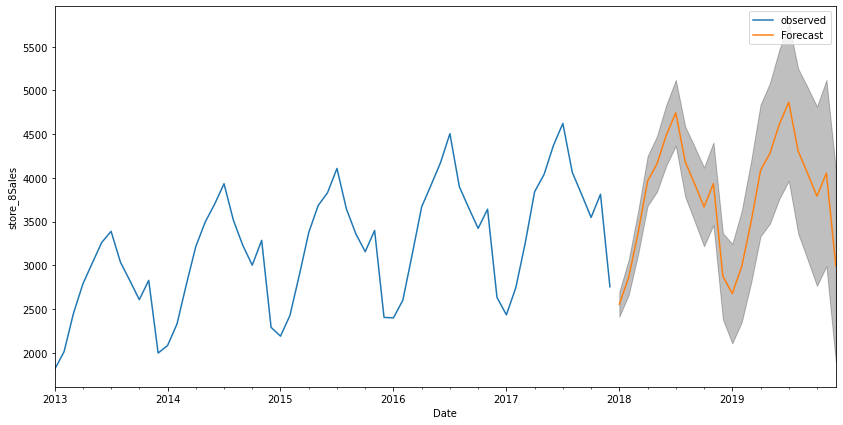

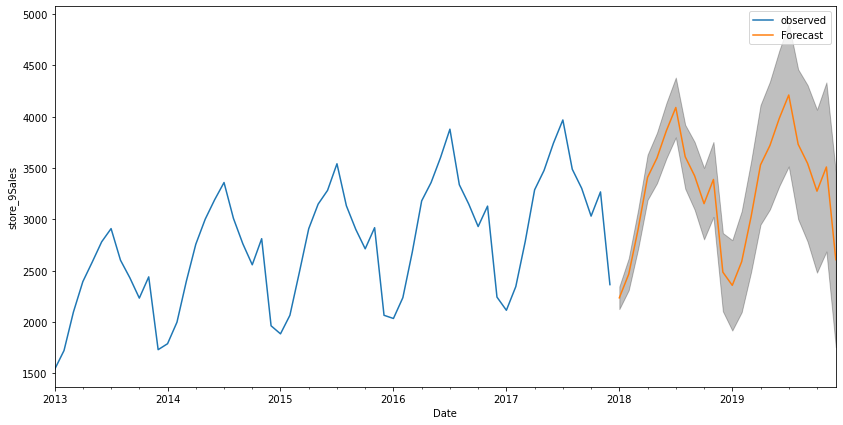

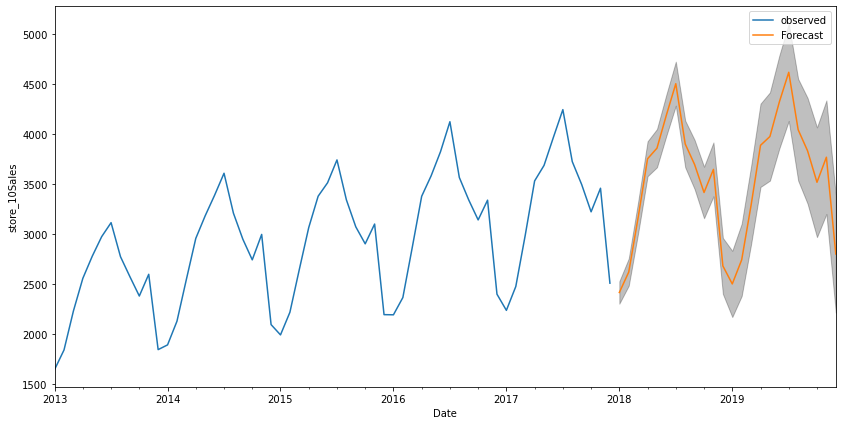

In [47]:
#Now let us forecast into the unknown future



from statsmodels.tsa.statespace.sarimax import SARIMAX

for i in df['store'].unique():
    store_i = df.loc[df['store'] == i]
    store_i = store_i.groupby('date')['sales'].sum().reset_index()
    store_i = store_i.set_index('date')
    store_i = store_i['sales'].resample('M').mean()
    store_i_train = store_i.iloc[:48]
    store_i_test = store_i.iloc[48:]
    start_i = len(store_i_train)
    end_i = len(store_i_train) + len(store_i_test) - 1

    
    store_i_model = auto_arima(store_i,m=12,seasonal=True)
    orders=[(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,0),(0,1,1)]
    seasonal_order=[(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(0,1,0,12),(2,1,0,12)]
    
    store_i_model_final = SARIMAX(store_i,order=orders[i-1],seasonal_order=seasonal_order[i-1],enforce_invertibility=False)
    store_i_result_final = store_i_model_final.fit()
    store_i_pred = store_i_result_final.get_forecast(steps=24)
    store_i_pred_ci = store_i_pred.conf_int()
    ax = store_i.plot(label='observed',figsize=(14,7))
    store_i_pred.predicted_mean.plot(ax=ax,label='Forecast')
    ax.fill_between(store_i_pred_ci.index,
               store_i_pred_ci.iloc[:,0],
               store_i_pred_ci.iloc[:,1],color='k',alpha=.25)
    ax.set_xlabel('Date')
    ax.set_ylabel('store_' +str(i)+ 'Sales')
    plt.legend()
    plt.show()
    
    
    
    
    
    
